# Two Moons Laplace: 5-Seed Evaluation

Fits the Laplace variants below (subset of weights x Hessian structure x tuning method) over 5 random seeds. Checkpoints use `two_moons_laplace_5seed/` and figures use the `5seed_two_moons_` prefix.

In [1]:
from pathlib import Path
import sys, os, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (TinyMLP, train_map, checkpoint_exists, load_checkpoint,
                    save_checkpoint, load_two_moons, seed_everything, standard_metrics,
                    plot_boundary, entropy_per_example, plot_reliability_diagrams,
                    build_laplace_variant)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [42, 711, 123, 456, 789]

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Separate checkpoint dir, no collision with single-seed two_moons_{vname}_seed42.pt
CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "two_moons_laplace_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
MAP_CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "two_moons_map_5seed")
os.makedirs(MAP_CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Two Moons Laplace | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")


Device: cuda
5-seed Two Moons Laplace | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/two_moons_laplace_5seed


In [2]:
def la_predict_fn(la_v, device):
    """Wrap a fitted Laplace model as a numpy-in, numpy-out predict function.

    Args:
        la_v: Fitted Laplace object (classification, GLM predictive).
        device: Device to run inference on.

    Returns:
        predict_fn(X_np) -> np.ndarray of P(class=1), processed in batches
        of 256 rows. Intended for callers that only work with numpy, such
        as plot_boundary.
    """
    def predict_fn(X_np):
        results = []
        with torch.no_grad():
            for i in range(0, len(X_np), 256):
                X_t = torch.tensor(X_np[i:i+256], dtype=torch.float32).to(device)
                p = la_v(X_t, pred_type="glm", link_approx="probit")
                results.append(p[:,1].detach().cpu())
        return torch.cat(results).numpy()
    return predict_fn

variant_specs = [
    {"variant_name": "gridsearch_diag_all_weights", "subset_of_weights": "all",
     "hessian_structure": "diag", "tune_method": "gridsearch",
     "plot_title": "Diag / all weights / gridsearch"},
    {"variant_name": "marglik_diag_all_weights", "subset_of_weights": "all",
     "hessian_structure": "diag", "tune_method": "marglik",
     "plot_title": "Diag / all weights / marglik"},
    {"variant_name": "gridsearch_full_all_weights", "subset_of_weights": "all",
     "hessian_structure": "full", "tune_method": "gridsearch",
     "plot_title": "Full / all weights / gridsearch"},
    {"variant_name": "marglik_full_all_weights", "subset_of_weights": "all",
     "hessian_structure": "full", "tune_method": "marglik",
     "plot_title": "Full / all weights / marglik"},
    {"variant_name": "gridsearch_kron_all_weights", "subset_of_weights": "all",
     "hessian_structure": "kron", "tune_method": "gridsearch",
     "plot_title": "Kron / all weights / gridsearch"},
    {"variant_name": "marglik_kron_all_weights", "subset_of_weights": "all",
     "hessian_structure": "kron", "tune_method": "marglik",
     "plot_title": "Kron / all weights / marglik"},
    {"variant_name": "gridsearch_full_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "full", "tune_method": "gridsearch",
     "plot_title": "Full / last layer / gridsearch"},
    {"variant_name": "marglik_full_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "full", "tune_method": "marglik",
     "plot_title": "Full / last layer / marglik"},
    {"variant_name": "gridsearch_kron_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "kron", "tune_method": "gridsearch",
     "plot_title": "Kron / last layer / gridsearch"},
    {"variant_name": "marglik_kron_last_layer", "subset_of_weights": "last_layer",
     "hessian_structure": "kron", "tune_method": "marglik",
     "plot_title": "Kron / last layer / marglik"},
]
print(f"Configured {len(variant_specs)} variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")

Configured 10 variants x 5 seeds = 50 total fits


In [3]:
all_seed_metrics = {}   # {seed: {vname: metrics_dict}}
all_seed_probs   = {}   # {seed: {vname: test_probs (N,2)}}
all_seed_la      = {}   # {seed: {vname: fitted Laplace object}}
all_seed_y_test  = {}   # {seed: y_test_np}

# Extended grid, same for all seeds (deterministic)
ext = 4.5
gx, gy = np.meshgrid(np.arange(-ext, ext, 0.1), np.arange(-ext, ext, 0.1))
epi_map_grid_np = np.c_[gx.ravel(), gy.ravel()]

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")
    seed_everything(seed)

    data = load_two_moons(seed=seed, noise=0.3, batch_train=32, batch_eval=64, device=device)
    X_train = data["X_train"]; X_val = data["X_val"]; X_test = data["X_test"]
    y_train = data["y_train"]; y_val   = data["y_val"]; y_test = data["y_test"]
    X_test_tensor = data["X_test_tensor"]
    y_test_np = y_test
    all_seed_y_test[seed] = y_test_np

    # ----- MAP -----
    map_ckpt = os.path.join(MAP_CHECKPOINT_BASE, f"two_moons_map_seed{seed}.pt")
    model, _, _ = train_map(
        TinyMLP(hidden=64).to(device), data["train_loader"],
        epochs=300, checkpoint_path=map_ckpt, device=device,
        val_loader=data["val_loader"], patience=25)
    model.eval()

    seed_metrics, seed_probs = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        ckpt_path = os.path.join(CHECKPOINT_BASE, f"two_moons_{vname}_seed{seed}.pt")

        la_v = build_laplace_variant(TinyMLP(hidden=64).to(device), model, spec, "classification")
        loaded = False
        if checkpoint_exists(ckpt_path):
            payload = load_checkpoint(ckpt_path, map_location=device)
            if isinstance(payload, dict) and payload.get("la_state_dict") is not None:
                la_v.load_state_dict(payload["la_state_dict"])
                v_metrics = payload.get("metrics", {})
                loaded = True

        if not loaded:
            t0 = time.time(); la_v.fit(data["train_loader"])
            v_metrics = {
                "Fit_Time (s)": time.time()-t0,
                "Subset_Of_Weights": spec["subset_of_weights"],
                "Hessian_Structure": spec["hessian_structure"],
                "Tune_Method": spec["tune_method"],
            }
            t1 = time.time()
            if spec["tune_method"] == "gridsearch":
                la_v.optimize_prior_precision(
                    method="gridsearch", pred_type="glm",
                    link_approx="probit", val_loader=data["val_loader"])
            else:
                la_v.optimize_prior_precision(method="marglik")
            v_metrics["Tune_Time (s)"] = time.time()-t1
            v_metrics["Prior_Precision"] = float(la_v.prior_precision.item())
            save_checkpoint({"la_state_dict": la_v.state_dict(),
                             "metrics": v_metrics}, ckpt_path)

        t_inf = time.time()
        with torch.no_grad():
            v_test_probs = la_v(X_test_tensor, pred_type="glm",
                                link_approx="probit").detach().cpu().numpy()
        v_metrics["Inf_Time (s)"] = time.time() - t_inf
        row = {**v_metrics, **standard_metrics(v_test_probs, y_test_np)}
        seed_metrics[vname] = row
        seed_probs[vname]   = v_test_probs
        all_seed_la.setdefault(seed, {})[vname] = la_v
        print(f"  {vname}: Acc={row.get('Accuracy',float('nan')):.4f}  "
              f"NLL={row.get('NLL',float('nan')):.4f}  "
              f"ECE={row.get('ECE',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_probs[seed]   = seed_probs

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 42  (1/5)


  gridsearch_diag_all_weights: Acc=0.9195  NLL=0.1916  ECE=0.0106
  marglik_diag_all_weights: Acc=0.9195  NLL=0.1963  ECE=0.0219
  gridsearch_full_all_weights: Acc=0.9195  NLL=0.1916  ECE=0.0104


  marglik_full_all_weights: Acc=0.9195  NLL=0.3679  ECE=0.2032
  gridsearch_kron_all_weights: Acc=0.9195  NLL=0.1916  ECE=0.0106
  marglik_kron_all_weights: Acc=0.9195  NLL=0.2733  ECE=0.1154
  gridsearch_full_last_layer: Acc=0.9195  NLL=0.1916  ECE=0.0105
  marglik_full_last_layer: Acc=0.9195  NLL=0.2229  ECE=0.0592
  gridsearch_kron_last_layer: Acc=0.9195  NLL=0.1916  ECE=0.0105
  marglik_kron_last_layer: Acc=0.9195  NLL=0.2171  ECE=0.0519

SEED 711  (2/5)
  gridsearch_diag_all_weights: Acc=0.9230  NLL=0.1974  ECE=0.0199
  marglik_diag_all_weights: Acc=0.9230  NLL=0.2033  ECE=0.0307


  gridsearch_full_all_weights: Acc=0.9230  NLL=0.1973  ECE=0.0199
  marglik_full_all_weights: Acc=0.9230  NLL=0.3991  ECE=0.2296
  gridsearch_kron_all_weights: Acc=0.9230  NLL=0.1974  ECE=0.0199
  marglik_kron_all_weights: Acc=0.9230  NLL=0.3005  ECE=0.1451
  gridsearch_full_last_layer: Acc=0.9230  NLL=0.1973  ECE=0.0199
  marglik_full_last_layer: Acc=0.9230  NLL=0.2409  ECE=0.0811
  gridsearch_kron_last_layer: Acc=0.9230  NLL=0.1973  ECE=0.0199
  marglik_kron_last_layer: Acc=0.9230  NLL=0.2338  ECE=0.0732

SEED 123  (3/5)
  gridsearch_diag_all_weights: Acc=0.9065  NLL=0.2332  ECE=0.0169


  marglik_diag_all_weights: Acc=0.9065  NLL=0.2331  ECE=0.0139
  gridsearch_full_all_weights: Acc=0.9065  NLL=0.2332  ECE=0.0169


  marglik_full_all_weights: Acc=0.9065  NLL=0.3908  ECE=0.1985
  gridsearch_kron_all_weights: Acc=0.9065  NLL=0.2332  ECE=0.0169
  marglik_kron_all_weights: Acc=0.9065  NLL=0.3031  ECE=0.1140
  gridsearch_full_last_layer: Acc=0.9065  NLL=0.2332  ECE=0.0172
  marglik_full_last_layer: Acc=0.9065  NLL=0.2508  ECE=0.0488
  gridsearch_kron_last_layer: Acc=0.9065  NLL=0.2332  ECE=0.0169
  marglik_kron_last_layer: Acc=0.9065  NLL=0.2465  ECE=0.0441

SEED 456  (4/5)
  gridsearch_diag_all_weights: Acc=0.9145  NLL=0.2064  ECE=0.0126
  marglik_diag_all_weights: Acc=0.9145  NLL=0.2105  ECE=0.0227
  gridsearch_full_all_weights: Acc=0.9145  NLL=0.2064  ECE=0.0126


  marglik_full_all_weights: Acc=0.9145  NLL=0.3501  ECE=0.1761
  gridsearch_kron_all_weights: Acc=0.9145  NLL=0.2064  ECE=0.0126
  marglik_kron_all_weights: Acc=0.9145  NLL=0.2703  ECE=0.0995
  gridsearch_full_last_layer: Acc=0.9145  NLL=0.2064  ECE=0.0126
  marglik_full_last_layer: Acc=0.9145  NLL=0.2217  ECE=0.0439
  gridsearch_kron_last_layer: Acc=0.9145  NLL=0.2064  ECE=0.0126
  marglik_kron_last_layer: Acc=0.9145  NLL=0.2184  ECE=0.0380

SEED 789  (5/5)
  gridsearch_diag_all_weights: Acc=0.9135  NLL=0.2037  ECE=0.0161
  marglik_diag_all_weights: Acc=0.9135  NLL=0.2078  ECE=0.0267


  gridsearch_full_all_weights: Acc=0.9135  NLL=0.2037  ECE=0.0152
  marglik_full_all_weights: Acc=0.9135  NLL=0.3963  ECE=0.2165
  gridsearch_kron_all_weights: Acc=0.9135  NLL=0.2037  ECE=0.0152
  marglik_kron_all_weights: Acc=0.9135  NLL=0.2972  ECE=0.1279
  gridsearch_full_last_layer: Acc=0.9135  NLL=0.2037  ECE=0.0152
  marglik_full_last_layer: Acc=0.9135  NLL=0.2369  ECE=0.0624
  gridsearch_kron_last_layer: Acc=0.9135  NLL=0.2037  ECE=0.0152
  marglik_kron_last_layer: Acc=0.9135  NLL=0.2312  ECE=0.0583

Completed 5 seeds x 10 variants.


In [4]:
metric_keys = ["Accuracy", "NLL", "Brier_Score", "ECE", "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)"]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]; agg[vname] = {}
    for mk in metric_keys:
        vals = [all_seed_metrics[s][vname].get(mk, float("nan")) for s in SEEDS]
        vals = [v for v in vals if not np.isnan(v)]
        agg[vname][f"{mk}_mean"] = float(np.mean(vals)) if vals else float("nan")
        agg[vname][f"{mk}_std"]  = float(np.std(vals))  if len(vals)>1 else 0.0

rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Two Moons Laplace — {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

agg_flat = [{"Variant": s["plot_title"], **agg[s["variant_name"]]} for s in variant_specs]
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/two_moons_laplace_5seed_metrics.csv")
print("\nSaved to results/metrics/two_moons_laplace_5seed_metrics.csv")


Two Moons Laplace — 5-seed metrics (mean ± std)


,Accuracy,NLL,Brier_Score,ECE,Fit_Time (s),Tune_Time (s),Inf_Time (s)
Variant,,,,,,,
Diag / all weights / gridsearch,0.9154 ± 0.0056,0.2065 ± 0.0143,0.0616 ± 0.0047,0.0152 ± 0.0033,0.2323 ± 0.0240,4.3410 ± 0.2467,0.0542 ± 0.0667
Diag / all weights / marglik,0.9154 ± 0.0056,0.2102 ± 0.0124,0.0620 ± 0.0044,0.0232 ± 0.0056,0.2262 ± 0.0178,0.0691 ± 0.0190,0.0207 ± 0.0001
Full / all weights / gridsearch,0.9154 ± 0.0056,0.2065 ± 0.0143,0.0616 ± 0.0047,0.0150 ± 0.0033,1180.6970 ± 7.9896,8.4144 ± 0.2540,0.0353 ± 0.0048
Full / all weights / marglik,0.9154 ± 0.0056,0.3808 ± 0.0189,0.1069 ± 0.0072,0.2048 ± 0.0180,1181.8281 ± 21.0321,1.8687 ± 0.1482,0.0331 ± 0.0001
Kron / all weights / gridsearch,0.9154 ± 0.0056,0.2065 ± 0.0143,0.0616 ± 0.0047,0.0150 ± 0.0033,0.5323 ± 0.0117,5.1690 ± 0.1252,0.0219 ± 0.0006
Kron / all weights / marglik,0.9154 ± 0.0056,0.2889 ± 0.0141,0.0777 ± 0.0046,0.1204 ± 0.0153,0.5174 ± 0.0196,0.0979 ± 0.0032,0.0218 ± 0.0004
Full / last layer / gridsearch,0.9154 ± 0.0056,0.2065 ± 0.0143,0.0616 ± 0.0047,0.0151 ± 0.0033,8.2472 ± 1.7061,1.5000 ± 0.0508,0.0007 ± 0.0001
Full / last layer / marglik,0.9154 ± 0.0056,0.2346 ± 0.0110,0.0657 ± 0.0038,0.0591 ± 0.0129,8.3209 ± 1.6572,0.0872 ± 0.0035,0.0006 ± 0.0000
Kron / last layer / gridsearch,0.9154 ± 0.0056,0.2065 ± 0.0143,0.0616 ± 0.0047,0.0150 ± 0.0033,0.4216 ± 0.0285,1.8870 ± 0.0333,0.0004 ± 0.0000



Saved to results/metrics/two_moons_laplace_5seed_metrics.csv


In [ ]:
ABBREV = {"gridsearch": "gs", "all weights": "aw", "last layer": "ll", "marglik": "ml"}
def abbreviate_title(t):
    for full, ab in ABBREV.items():
        t = t.replace(full, ab)
    return t.replace(" / ", "/")

plot_metrics = ["Accuracy", "NLL", "ECE"]
titles = [abbreviate_title(s["plot_title"]) for s in variant_specs]
x = np.arange(len(titles))

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels(titles, fontsize=12, rotation=30, ha="right")
    ax.set_ylabel(mk)
    ax.set_title(f"Two Moons Laplace — {mk}  (mean ± std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_two_moons_laplace_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


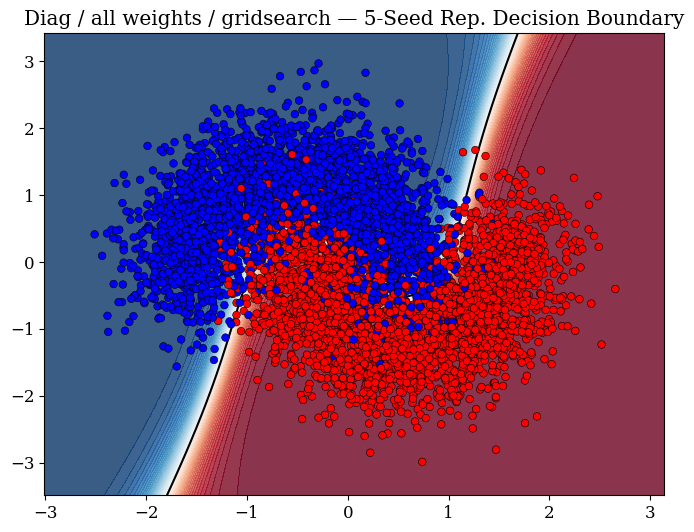

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_boundary.png


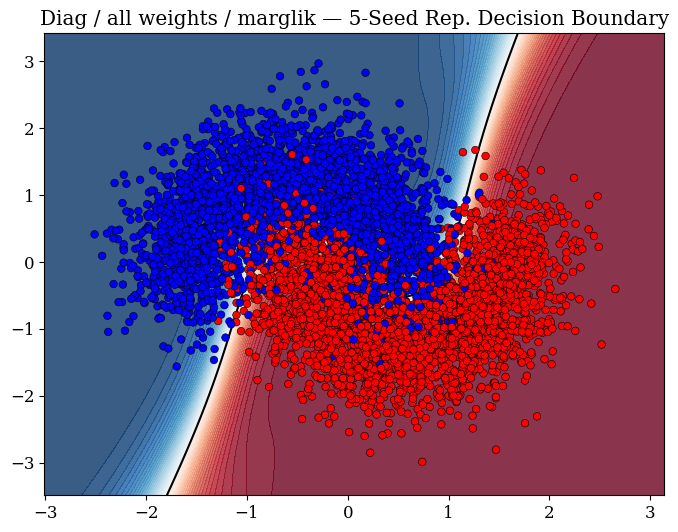

  Saved: 5seed_two_moons_marglik_diag_all_weights_boundary.png


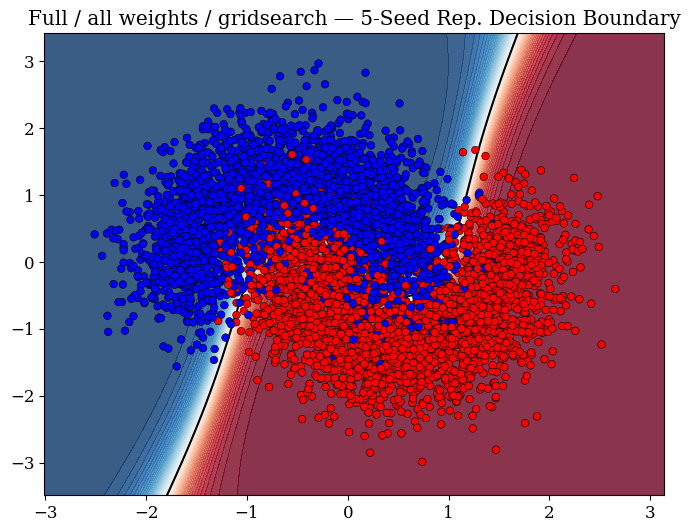

  Saved: 5seed_two_moons_gridsearch_full_all_weights_boundary.png


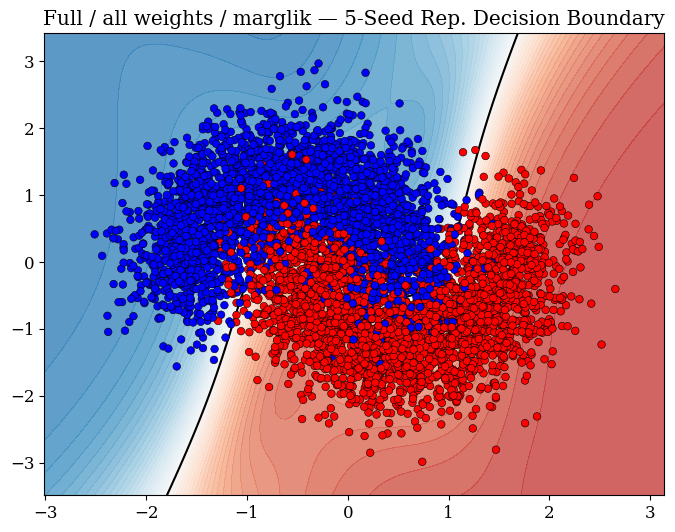

  Saved: 5seed_two_moons_marglik_full_all_weights_boundary.png


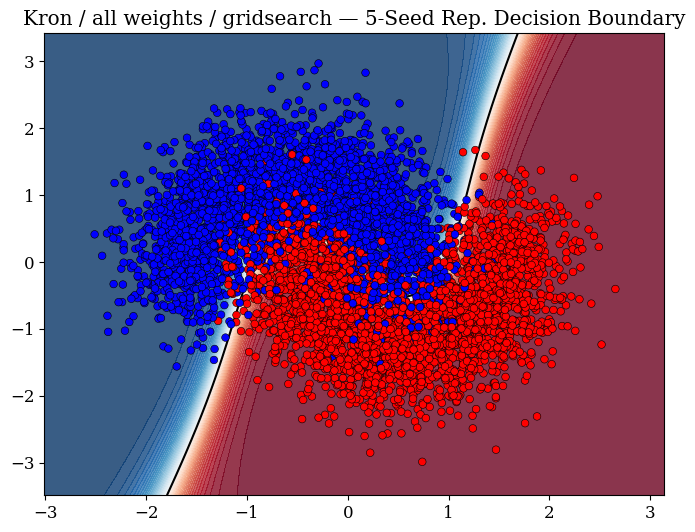

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_boundary.png


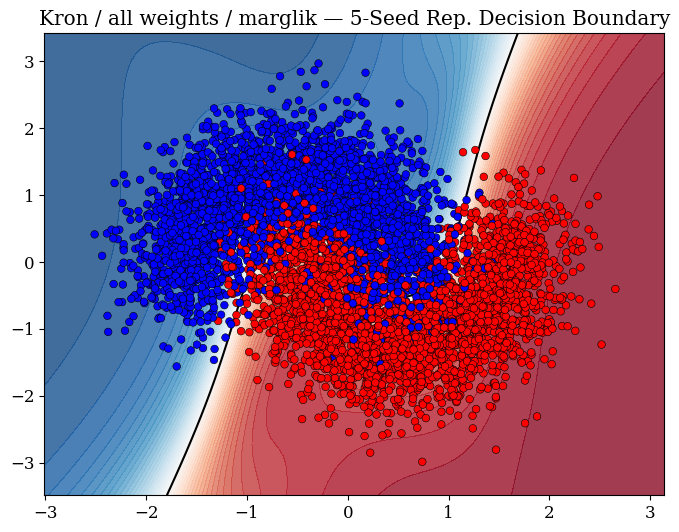

  Saved: 5seed_two_moons_marglik_kron_all_weights_boundary.png


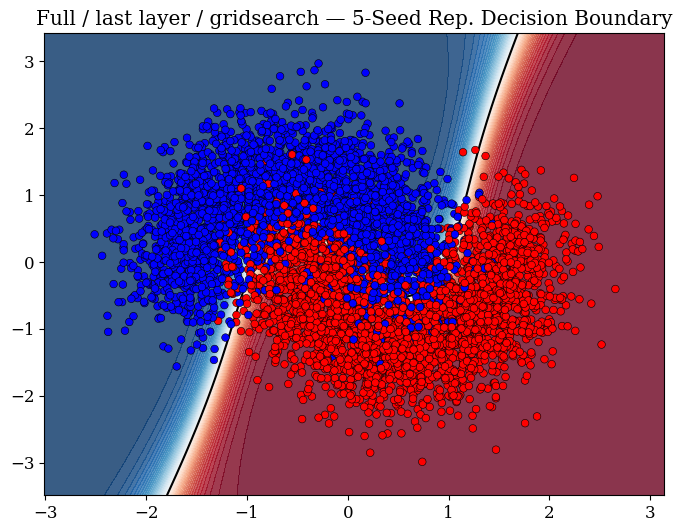

  Saved: 5seed_two_moons_gridsearch_full_last_layer_boundary.png


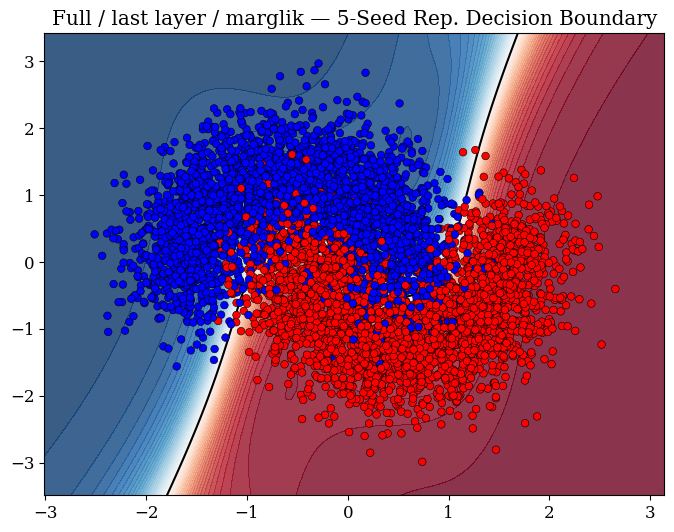

  Saved: 5seed_two_moons_marglik_full_last_layer_boundary.png


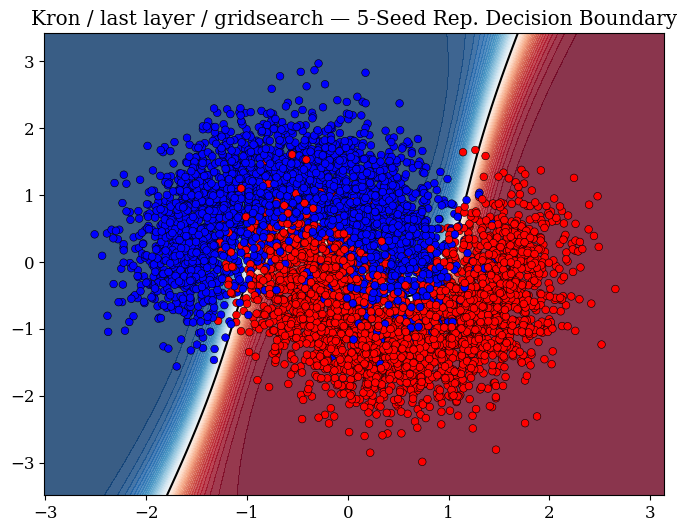

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_boundary.png


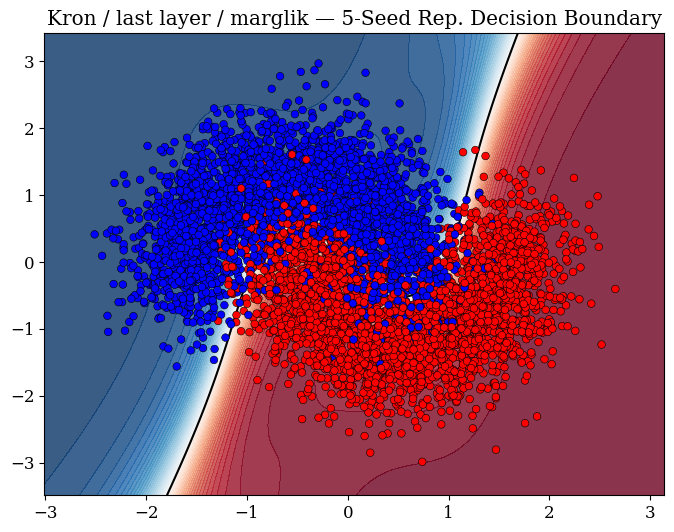

  Saved: 5seed_two_moons_marglik_kron_last_layer_boundary.png

Done: 10 boundary figures


In [6]:
# Per-variant representative decision boundary (last seed)
seed_last = SEEDS[-1]
data_last = load_two_moons(seed=seed_last, noise=0.3, batch_train=32, batch_eval=64, device=device)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]
    la_last = all_seed_la.get(seed_last, {}).get(vname)
    if la_last is None:
        print(f"  Skipping {vname} (not in memory)"); continue

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    predict_fn = la_predict_fn(la_last, device)
    plot_boundary(predict_fn, data_last["X_train"], data_last["y_train"],
                  f"{title} — 5-Seed Rep. Decision Boundary", ax=ax)
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_boundary.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_boundary.png")
print(f"\nDone: {len(variant_specs)} boundary figures")

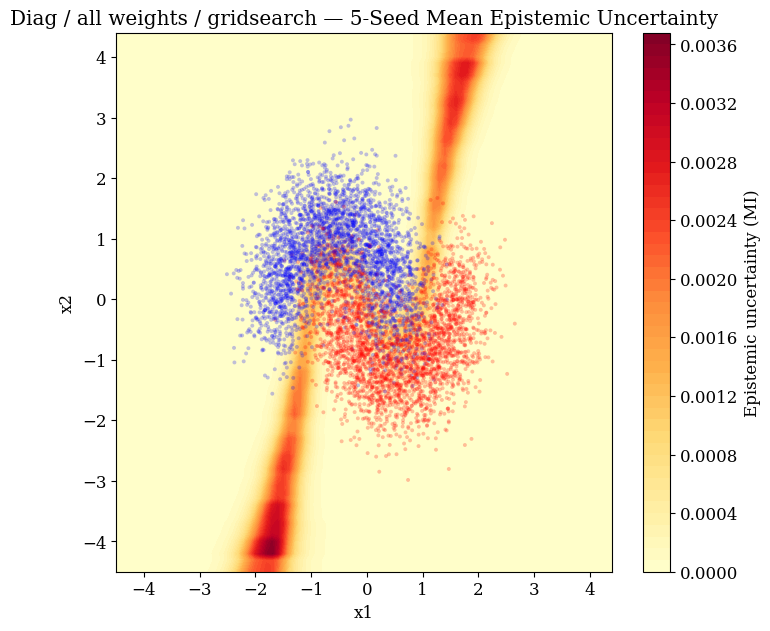

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_epistemic_map.png


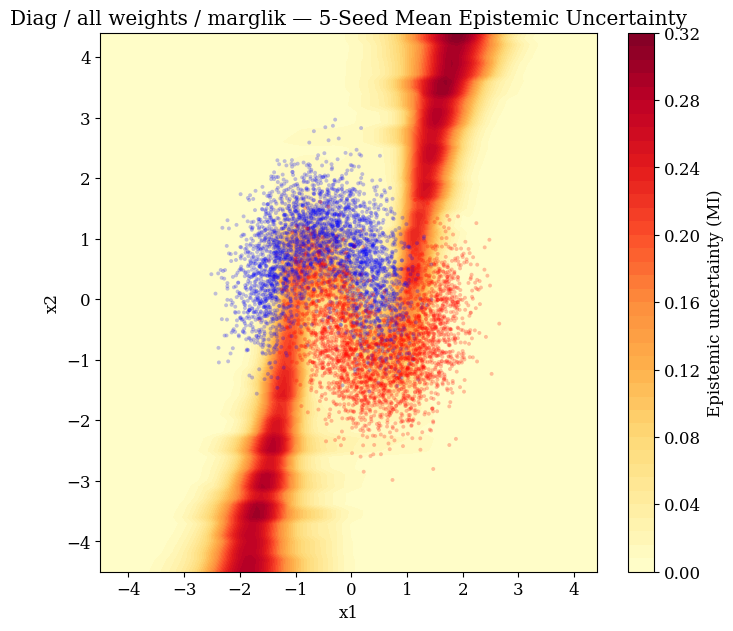

  Saved: 5seed_two_moons_marglik_diag_all_weights_epistemic_map.png


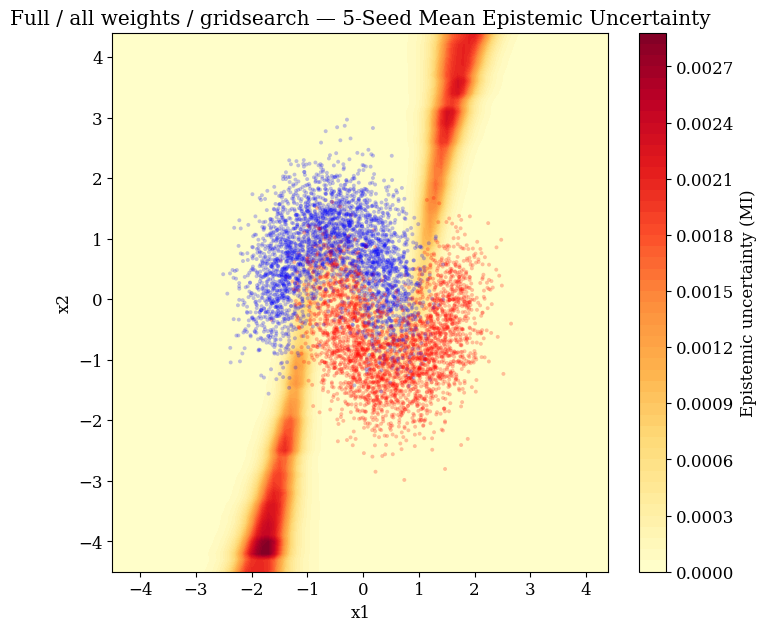

  Saved: 5seed_two_moons_gridsearch_full_all_weights_epistemic_map.png


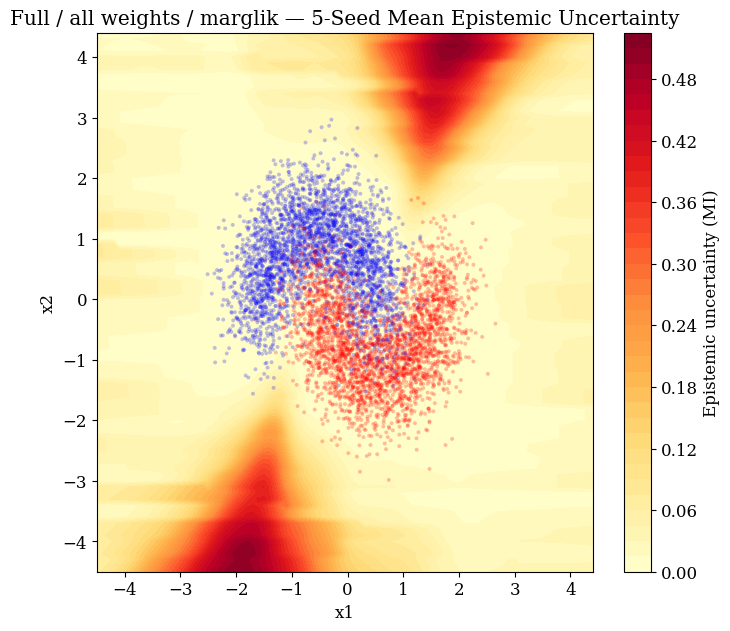

  Saved: 5seed_two_moons_marglik_full_all_weights_epistemic_map.png


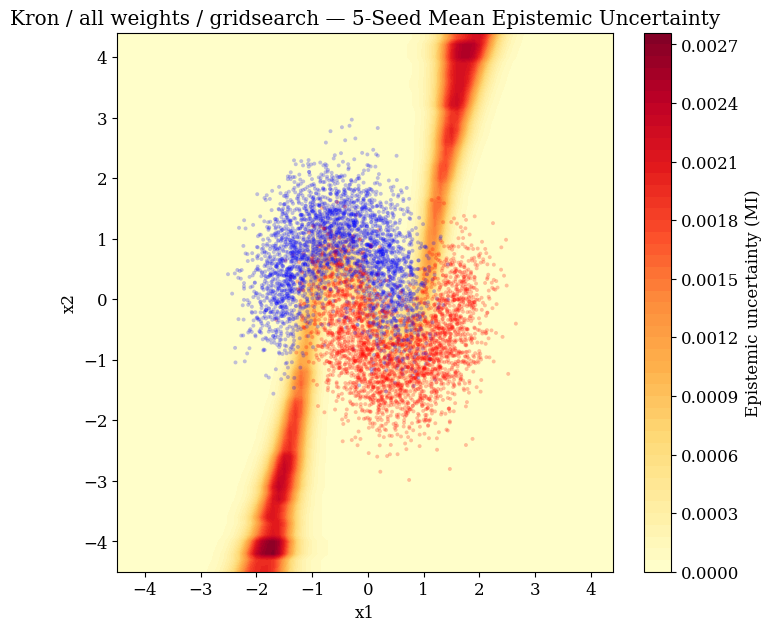

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_epistemic_map.png


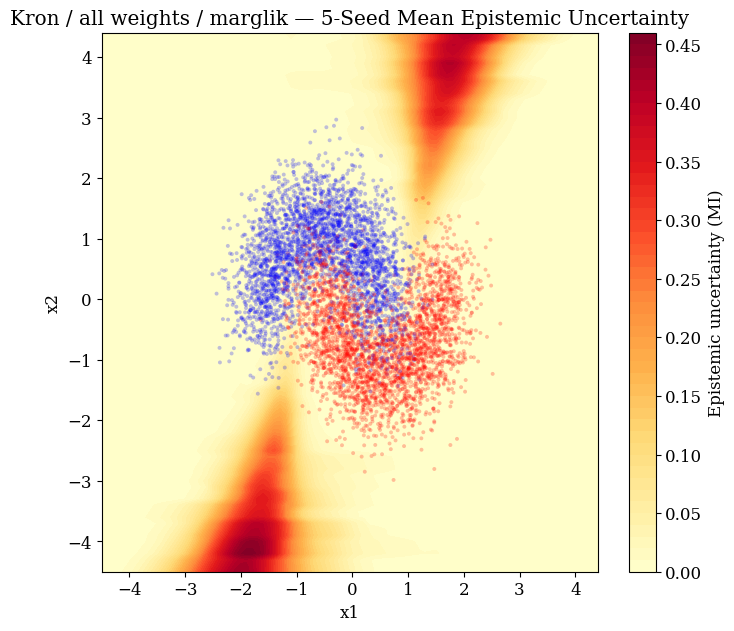

  Saved: 5seed_two_moons_marglik_kron_all_weights_epistemic_map.png


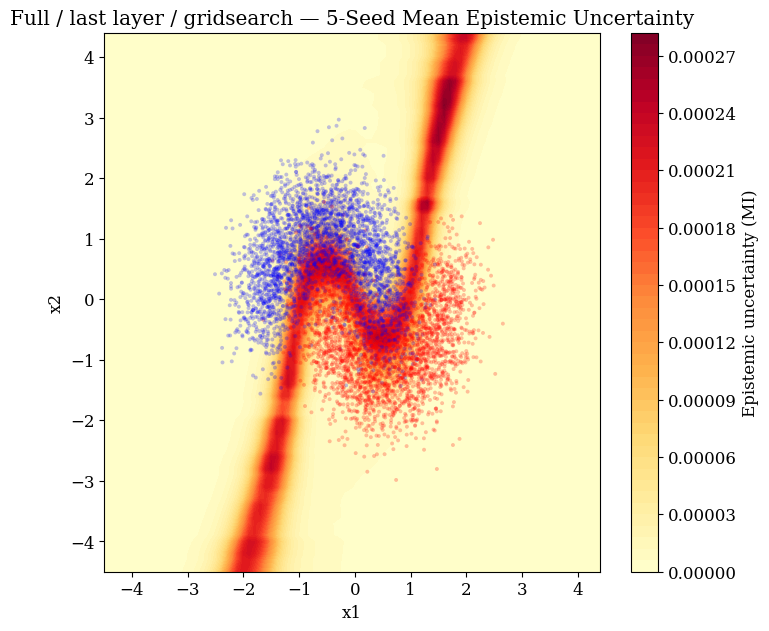

  Saved: 5seed_two_moons_gridsearch_full_last_layer_epistemic_map.png


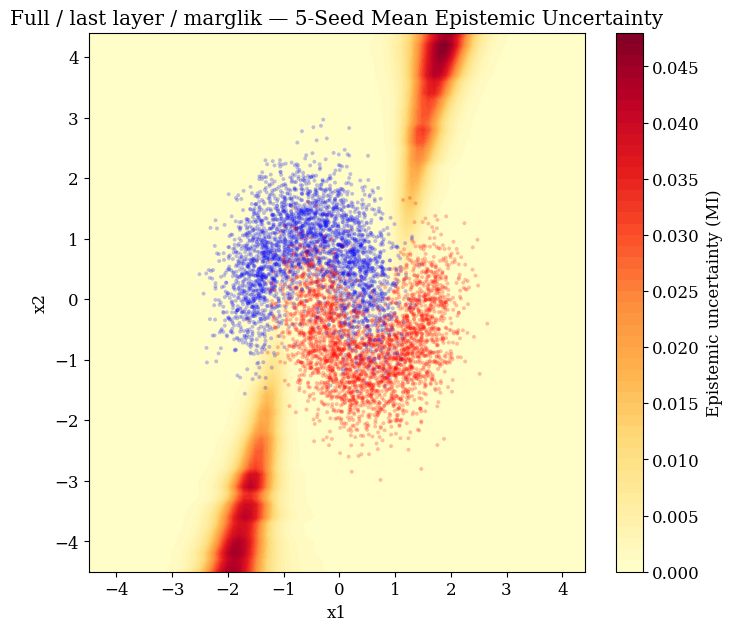

  Saved: 5seed_two_moons_marglik_full_last_layer_epistemic_map.png


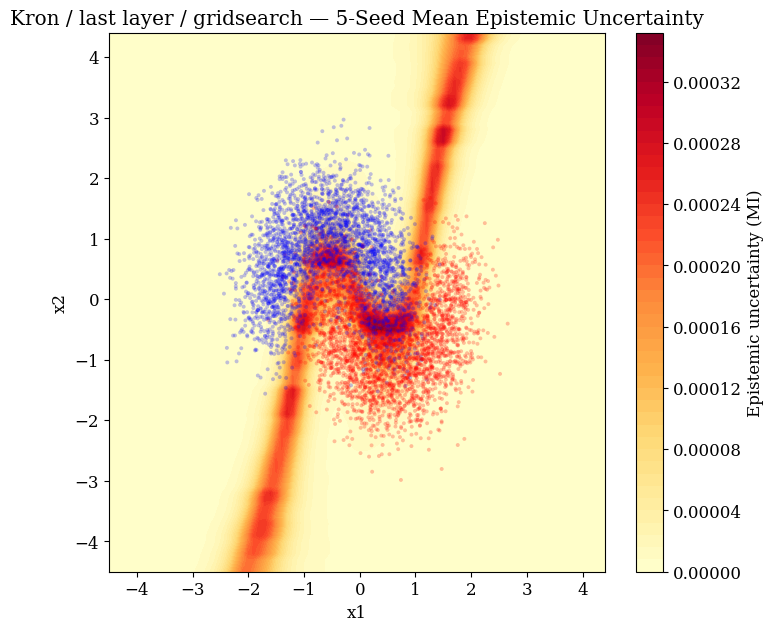

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_epistemic_map.png


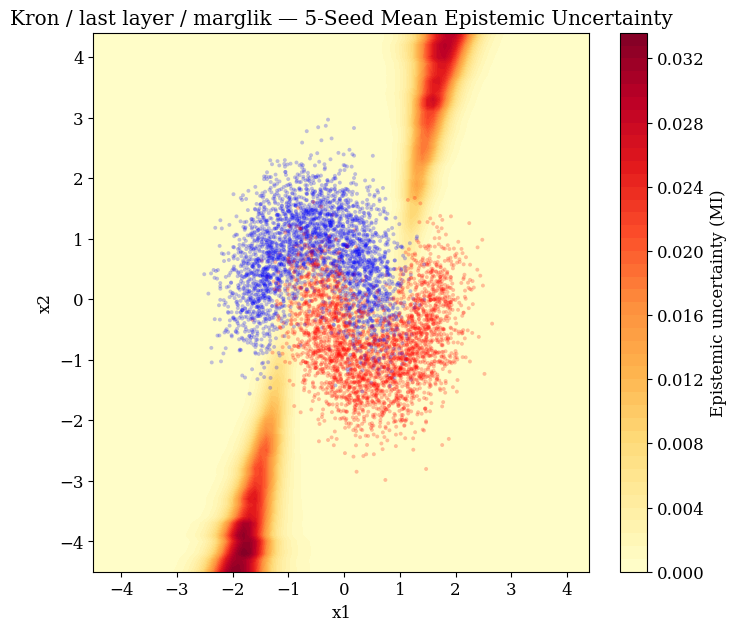

  Saved: 5seed_two_moons_marglik_kron_last_layer_epistemic_map.png

Done: 10 epistemic uncertainty figures


In [7]:
# Per-variant epistemic uncertainty maps: average across seeds on a grid
# extending beyond the training data
epi_map_grid_tensor = torch.tensor(epi_map_grid_np, dtype=torch.float32).to(device)

def epistemic_on_grid(la_v, grid_t, n_samples=50, batch_size=256):
    """Mean epistemic uncertainty (mutual information) at each grid point.

    Computed as entropy of the MC-mean predictive minus the mean entropy of
    the individual MC samples: the epistemic term of the standard
    total = aleatoric + epistemic predictive-entropy decomposition.

    Args:
        la_v: Fitted Laplace object.
        grid_t: Grid points to evaluate, as a tensor.
        n_samples: Number of MC predictive samples per point.
        batch_size: Rows per batch, to bound memory use.

    Returns:
        np.ndarray of epistemic uncertainty, one value per grid point.
    """
    parts = []
    with torch.no_grad():
        for i in range(0, len(grid_t), batch_size):
            s = la_v.predictive_samples(grid_t[i:i+batch_size], pred_type="glm", n_samples=n_samples)
            parts.append(s.detach().cpu().numpy())
    samples = np.concatenate(parts, axis=1)
    mean_p = samples.mean(axis=0)
    return entropy_per_example(mean_p) - entropy_per_example(samples).mean(axis=0)

for spec in variant_specs:
    vname = spec["variant_name"]; title = spec["plot_title"]

    all_epi_grids = []
    for seed in SEEDS:
        la_v_s = all_seed_la.get(seed, {}).get(vname)
        if la_v_s is None:
            continue
        epi = epistemic_on_grid(la_v_s, epi_map_grid_tensor)
        all_epi_grids.append(epi)

    if not all_epi_grids:
        print(f"  Skipping {vname} (no data)"); continue
    mean_epi = np.stack(all_epi_grids).mean(axis=0).reshape(gx.shape)

    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    cf = ax.contourf(gx, gy, mean_epi, levels=50, cmap="YlOrRd")
    ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr",
               s=8, alpha=0.25, edgecolors="none")
    plt.colorbar(cf, ax=ax, label="Epistemic uncertainty (MI)")
    ax.set_title(f"{title} — 5-Seed Mean Epistemic Uncertainty")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    fig.savefig(os.path.join(FIGURES_DIR, f"5seed_two_moons_{vname}_epistemic_map.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: 5seed_two_moons_{vname}_epistemic_map.png")
print(f"\nDone: {len(variant_specs)} epistemic uncertainty figures")

/u/halle/carg/home_at/Documents/BNNs/shared/plotting.py:48: RuntimeWarning: Mean of empty slice
  mean_obs  = np.nanmean(all_accs, axis=0)
/u/halle/carg/home_at/anaconda3/envs/bnn/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


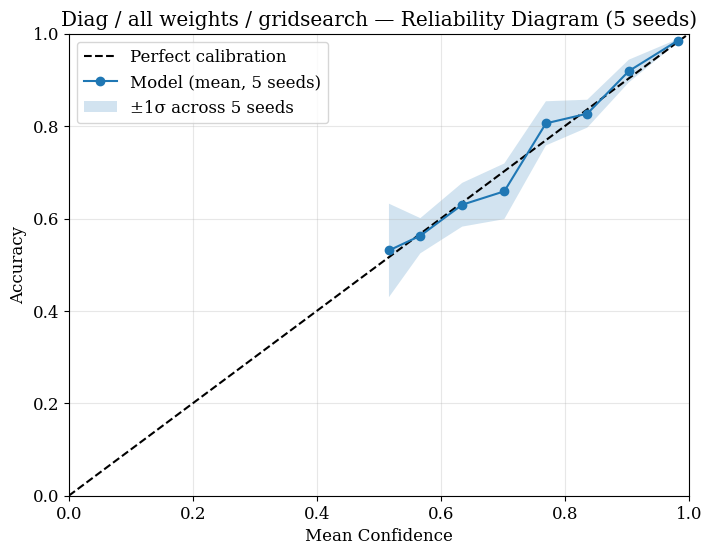

  Saved: 5seed_two_moons_gridsearch_diag_all_weights_reliability.png


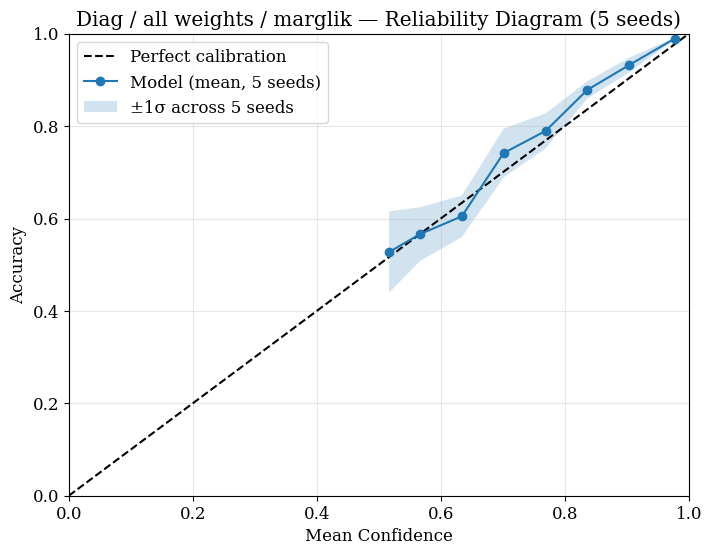

  Saved: 5seed_two_moons_marglik_diag_all_weights_reliability.png


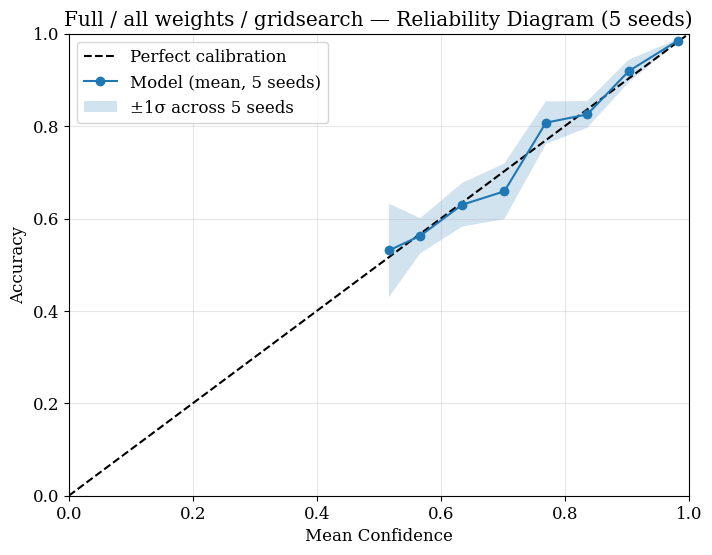

  Saved: 5seed_two_moons_gridsearch_full_all_weights_reliability.png


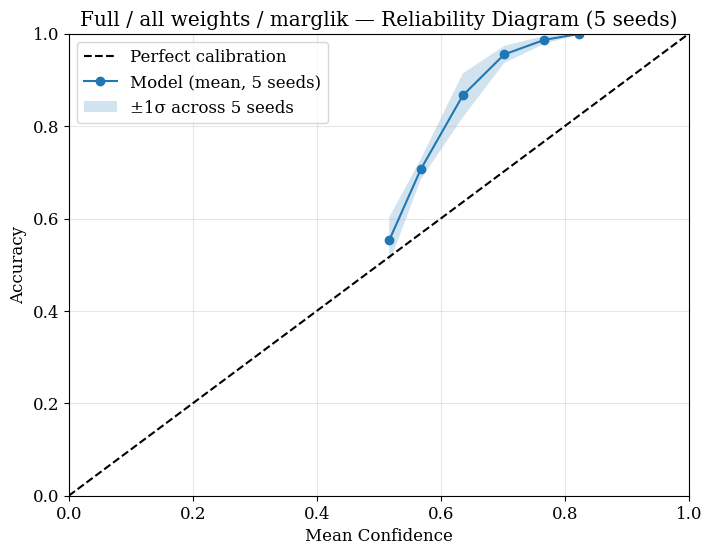

  Saved: 5seed_two_moons_marglik_full_all_weights_reliability.png


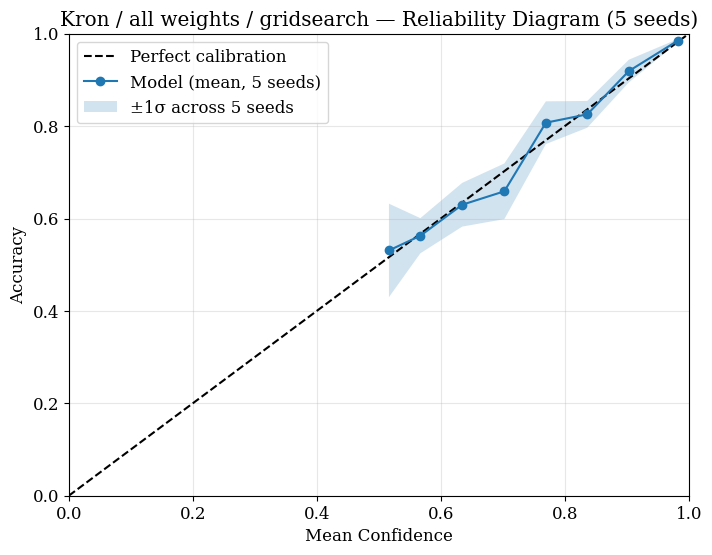

  Saved: 5seed_two_moons_gridsearch_kron_all_weights_reliability.png


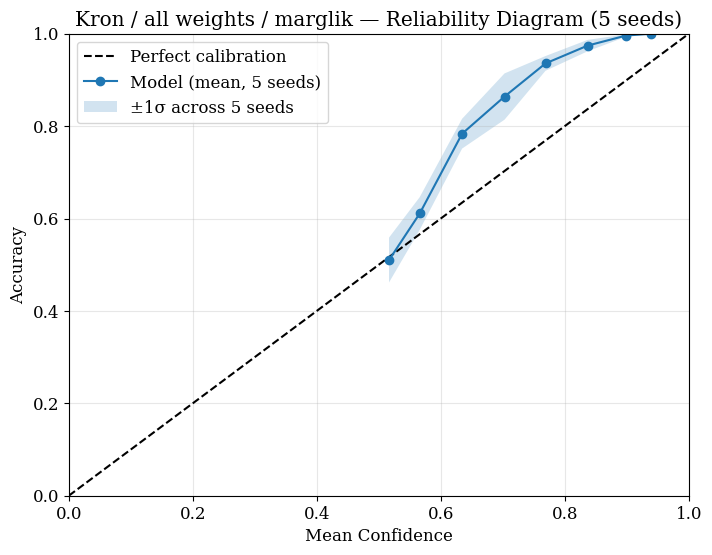

  Saved: 5seed_two_moons_marglik_kron_all_weights_reliability.png


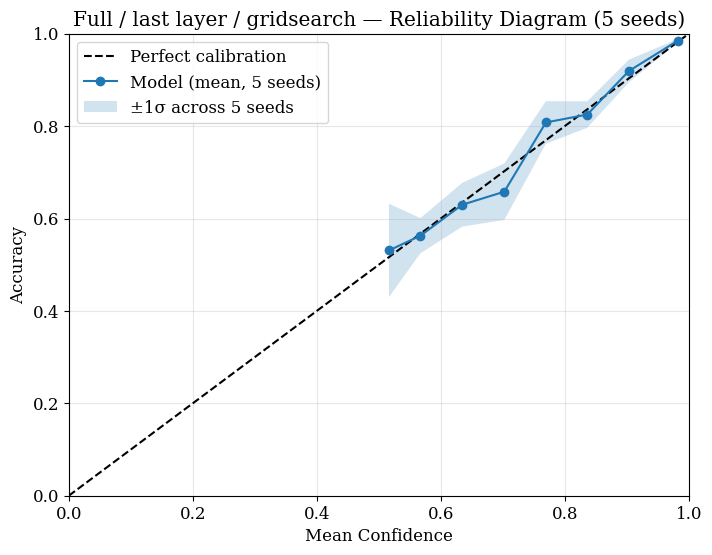

  Saved: 5seed_two_moons_gridsearch_full_last_layer_reliability.png


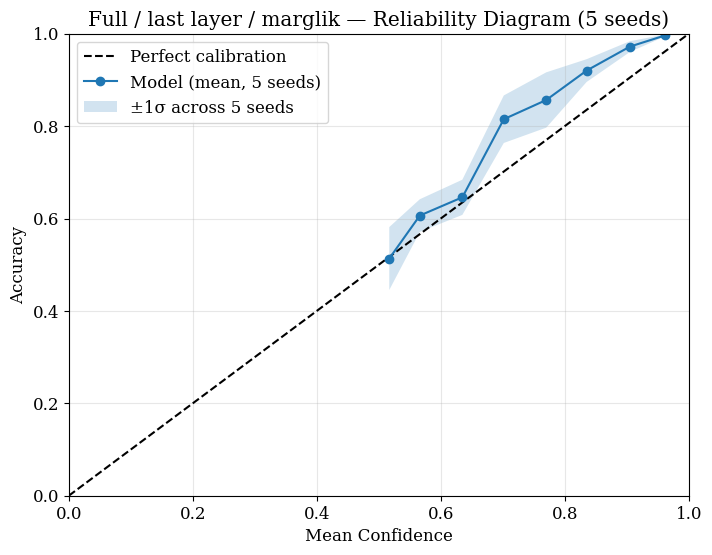

  Saved: 5seed_two_moons_marglik_full_last_layer_reliability.png


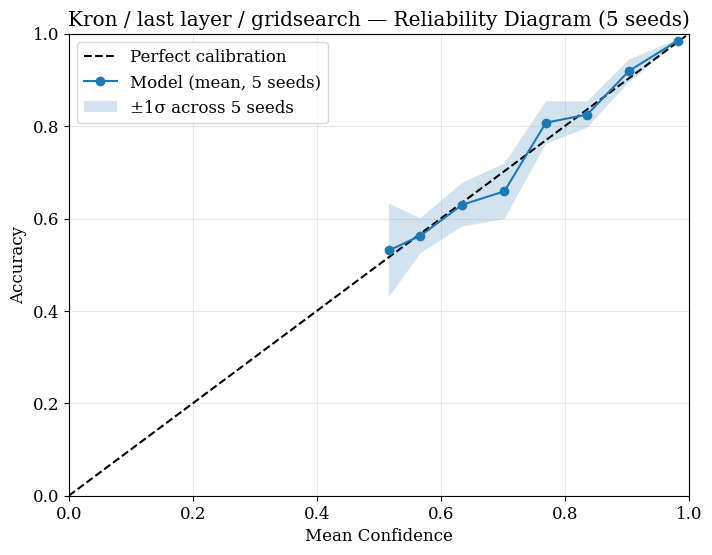

  Saved: 5seed_two_moons_gridsearch_kron_last_layer_reliability.png


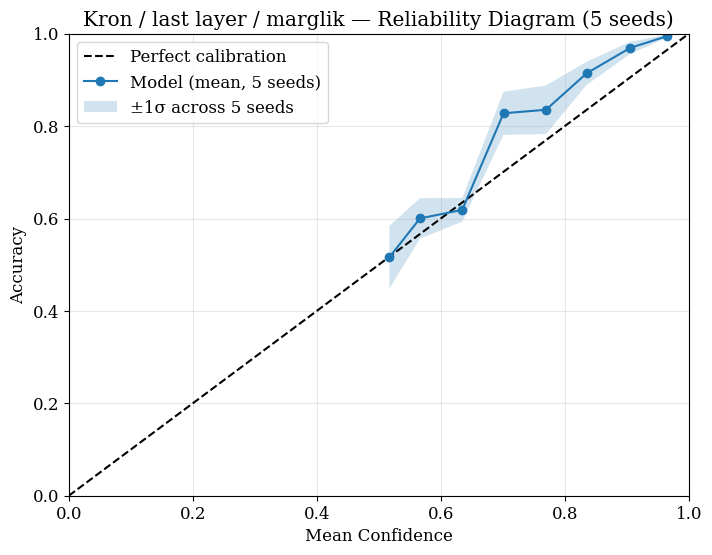

  Saved: 5seed_two_moons_marglik_kron_last_layer_reliability.png

Done: 10 reliability figures


In [8]:
plot_reliability_diagrams(variant_specs, all_seed_probs, all_seed_y_test, SEEDS, FIGURES_DIR, "5seed_two_moons")
